In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("./Testdaten.xlsx")
cols = ["Browser", "Strategie", "Sprache", "Mittelwert", "Median", "STD Abw"]

df.loc[(df["Browser"] == "Firefox") & (df["Datenpunkte"] == "1,5M"), cols]

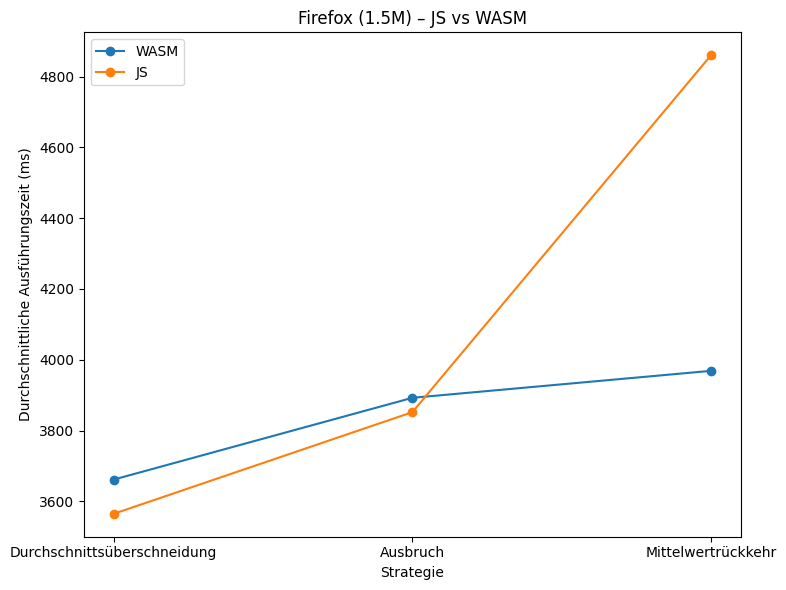

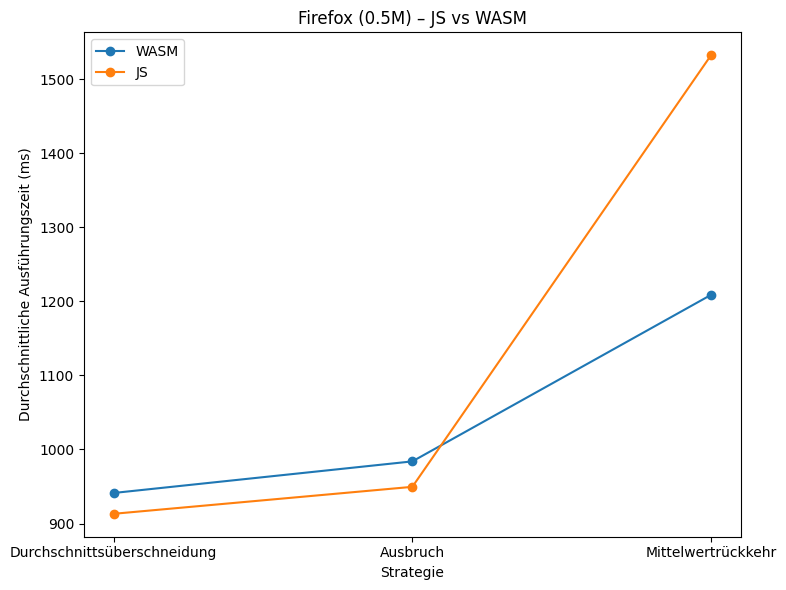

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("./Testdaten.xlsx")

def make_pivot(df, datenpunkte):
    filtered = df.loc[
        (df["Browser"] == "Firefox") &
        (df["Datenpunkte"] == datenpunkte),
        ["Strategie", "Sprache", "Mittelwert"]
    ]
    pivot = filtered.pivot(
        index="Strategie",
        columns="Sprache",
        values="Mittelwert"
    )
    pivot["Mean_Total"] = pivot.mean(axis=1)

    strategy_order = [
        "Durchschnittsüberschneidung",
        "Ausbruch",
        "Mittelwertrückkehr",
    ]
    return pivot.reindex([s for s in strategy_order if s in pivot.index])


pivot_15 = make_pivot(df, "1,5M")
pivot_05 = make_pivot(df, "0,5M")

# Diagramm 1: 1.5M
plt.figure(figsize=(8, 6))
plt.plot(pivot_15.index, pivot_15["WASM"], marker="o", label="WASM")
plt.plot(pivot_15.index, pivot_15["JS"], marker="o", label="JS")
plt.xlabel("Strategie")
plt.ylabel("Durchschnittliche Ausführungszeit (ms)")
plt.title("Firefox (1.5M) – JS vs WASM")
plt.legend()
plt.tight_layout()
plt.show()

# Diagramm 2: 0.5M
plt.figure(figsize=(8, 6))
plt.plot(pivot_05.index, pivot_05["WASM"], marker="o", label="WASM")
plt.plot(pivot_05.index, pivot_05["JS"], marker="o", label="JS")
plt.xlabel("Strategie")
plt.ylabel("Durchschnittliche Ausführungszeit (ms)")
plt.title("Firefox (0.5M) – JS vs WASM")
plt.legend()
plt.tight_layout()
plt.show()


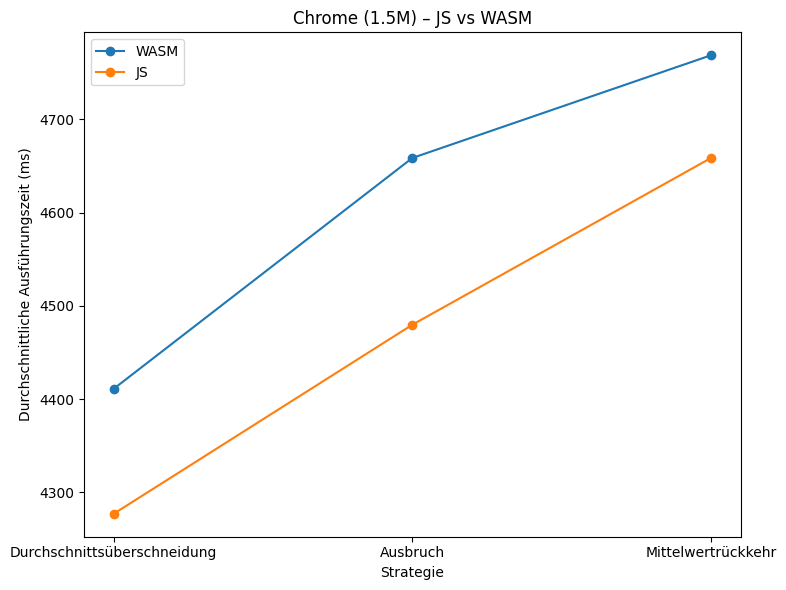

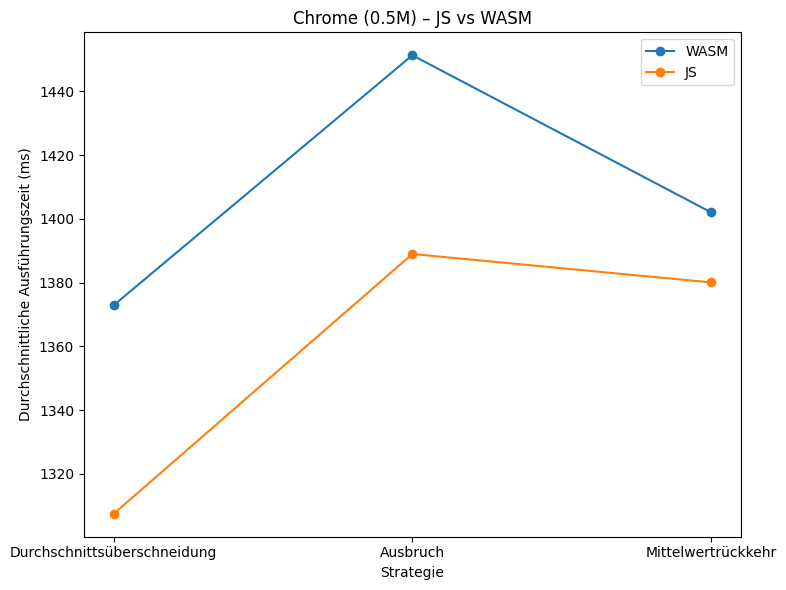

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("./Testdaten.xlsx")

def make_pivot(df, datenpunkte):
    filtered = df.loc[
        (df["Browser"] == "Chrome") &
        (df["Datenpunkte"] == datenpunkte),
        ["Strategie", "Sprache", "Mittelwert"]
    ]
    pivot = filtered.pivot(
        index="Strategie",
        columns="Sprache",
        values="Mittelwert"
    )
    pivot["Mean_Total"] = pivot.mean(axis=1)

    strategy_order = [
        "Durchschnittsüberschneidung",
        "Ausbruch",
        "Mittelwertrückkehr",
    ]
    return pivot.reindex([s for s in strategy_order if s in pivot.index])


pivot_15 = make_pivot(df, "1,5M")
pivot_05 = make_pivot(df, "0,5M")

# Diagramm 1: 1.5M
plt.figure(figsize=(8, 6))
plt.plot(pivot_15.index, pivot_15["WASM"], marker="o", label="WASM")
plt.plot(pivot_15.index, pivot_15["JS"], marker="o", label="JS")
plt.xlabel("Strategie")
plt.ylabel("Durchschnittliche Ausführungszeit (ms)")
plt.title("Chrome (1.5M) – JS vs WASM")
plt.legend()
plt.tight_layout()
plt.show()

# Diagramm 2: 0.5M
plt.figure(figsize=(8, 6))
plt.plot(pivot_05.index, pivot_05["WASM"], marker="o", label="WASM")
plt.plot(pivot_05.index, pivot_05["JS"], marker="o", label="JS")
plt.xlabel("Strategie")
plt.ylabel("Durchschnittliche Ausführungszeit (ms)")
plt.title("Chrome (0.5M) – JS vs WASM")
plt.legend()
plt.tight_layout()
plt.show()


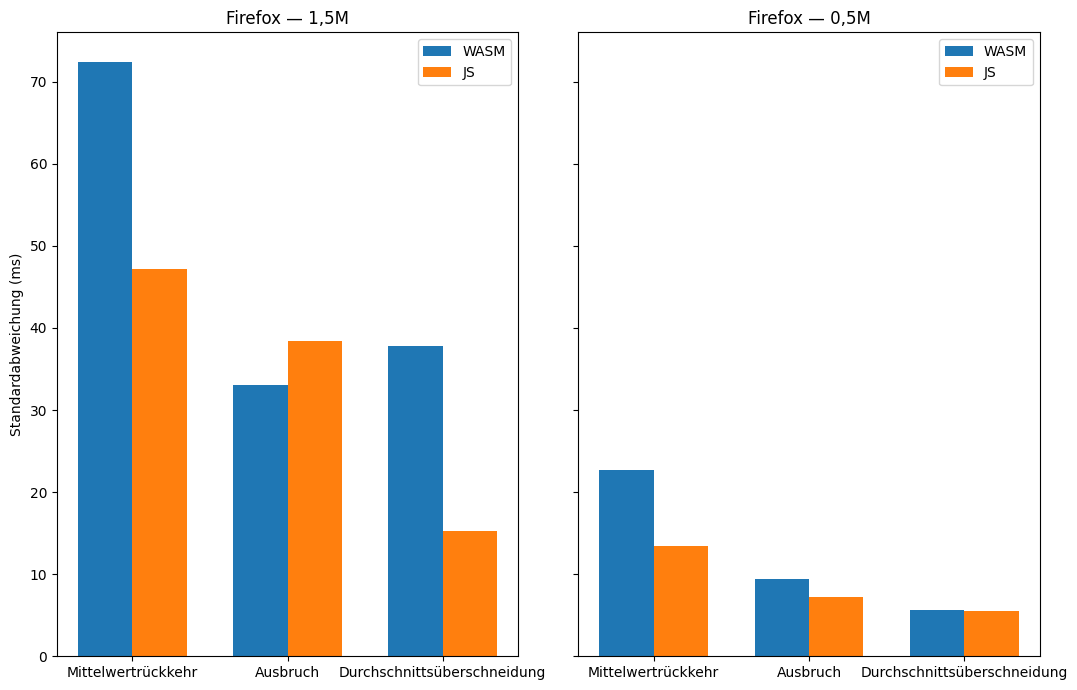

In [14]:
# Firefox: Gruppierte Balken für 1,5M und 0,5M als Subplots (WASM vs JS)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def pivot_std(browser, datenpunkte):
    df_sub = df.loc[(df['Browser'] == browser) & (df['Datenpunkte'] == datenpunkte), ['Strategie', 'Sprache', 'Standartabweichung']].copy()
    df_sub['Standartabweichung'] = pd.to_numeric(df_sub['Standartabweichung'].astype(str).str.replace(',', '.'), errors='coerce')
    return df_sub.pivot_table(index='Strategie', columns='Sprache', values='Standartabweichung', aggfunc='mean')
p15 = pivot_std('Firefox', '1,5M')
p05 = pivot_std('Firefox', '0,5M')
# einheitliche Reihenfolge der Strategien basierend auf kombinierter Mittelstreuung
combined_means = pd.concat([p15.mean(axis=1), p05.mean(axis=1)], axis=0).groupby(level=0).mean()
order = combined_means.sort_values(ascending=False).index
p15 = p15.reindex(order)
p05 = p05.reindex(order)
x = np.arange(len(order))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(11, 7), sharey=True)
# Left: 1.5M
axes[0].bar(x - width/2, p15.get('WASM', pd.Series(index=order)), width, label='WASM')
axes[0].bar(x + width/2, p15.get('JS', pd.Series(index=order)), width, label='JS')
axes[0].set_xticks(x)
axes[0].set_xticklabels(order, ha='center')
axes[0].set_title('Firefox — 1,5M')
axes[0].set_ylabel('Standardabweichung (ms)')
axes[0].legend()
# Right: 0.5M
axes[1].bar(x - width/2, p05.get('WASM', pd.Series(index=order)), width, label='WASM')
axes[1].bar(x + width/2, p05.get('JS', pd.Series(index=order)), width, label='JS')
axes[1].set_xticks(x)
axes[1].set_xticklabels(order, ha='center')
axes[1].set_title('Firefox — 0,5M')
axes[1].legend()
plt.tight_layout()
plt.show()


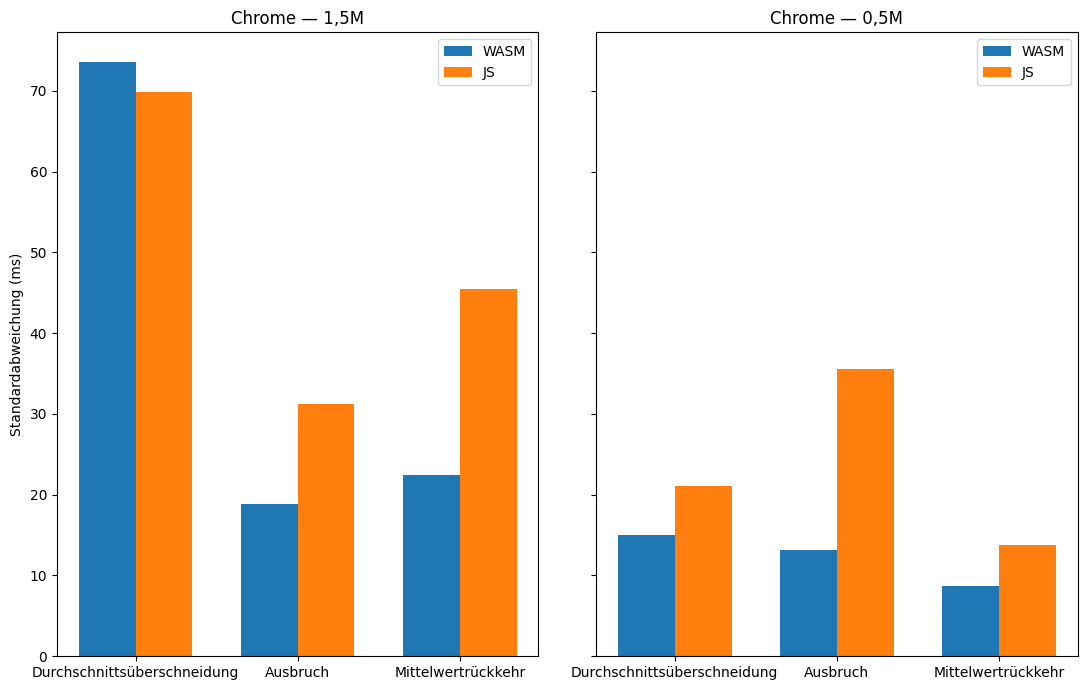

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def pivot_std(browser, datenpunkte):
    df_sub = df.loc[(df['Browser'] == browser) & (df['Datenpunkte'] == datenpunkte), ['Strategie', 'Sprache', 'Standartabweichung']].copy()
    df_sub['Standartabweichung'] = pd.to_numeric(df_sub['Standartabweichung'].astype(str).str.replace(',', '.'), errors='coerce')
    return df_sub.pivot_table(index='Strategie', columns='Sprache', values='Standartabweichung', aggfunc='mean')
p15 = pivot_std('Chrome', '1,5M')
p05 = pivot_std('Chrome', '0,5M')
# einheitliche Reihenfolge der Strategien basierend auf kombinierter Mittelstreuung
combined_means = pd.concat([p15.mean(axis=1), p05.mean(axis=1)], axis=0).groupby(level=0).mean()
order = combined_means.sort_values(ascending=False).index
p15 = p15.reindex(order)
p05 = p05.reindex(order)
x = np.arange(len(order))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(11, 7), sharey=True)
# Left: 1.5M
axes[0].bar(x - width/2, p15.get('WASM', pd.Series(index=order)), width, label='WASM')
axes[0].bar(x + width/2, p15.get('JS', pd.Series(index=order)), width, label='JS')
axes[0].set_xticks(x)
axes[0].set_xticklabels(order, ha='center')
axes[0].set_title('Chrome — 1,5M')
axes[0].set_ylabel('Standardabweichung (ms)')
axes[0].legend()
# Right: 0.5M
axes[1].bar(x - width/2, p05.get('WASM', pd.Series(index=order)), width, label='WASM')
axes[1].bar(x + width/2, p05.get('JS', pd.Series(index=order)), width, label='JS')
axes[1].set_xticks(x)
axes[1].set_xticklabels(order, ha='center')
axes[1].set_title('Chrome — 0,5M')
axes[1].legend()
plt.tight_layout()
plt.show()
